### 1. Import Packages & Functions

##### 1.1 Import Packages

In [1]:
from IPython.display import display            
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import dirichlet

##### 1.2 Import Functions

In [2]:
# From data.py, data processing
from data import (
    load_data, 
    aggregate_to_oevk, 
    aggregate_ep_votes_by_year, 
    delete_null_megye_or_votes, 
    categorize_party_result, 
    categorize_party_polls, 
    transform_wide_to_long,
    clean_candidates,
    create_incumbent_dummy)

# From model.py, modeling
from model import (
    pollster_bias, 
    pollster_quality, 
    pollster_sigma,
    polling_avg,
    forecast_distr,
    correl_parties,
    swing_coef,
    OEVK_projection,
    simulation,
    calibrate_sigma_d,
    backtesting)

# From seat_allocation.py, seat allocation
from seat_allocation import(
    seat_simulated
)


### 2. Data Processing

##### 2.1 Load Data Frames

In [3]:
df_oevk, df_national, df_ep, df_seats, df_polls, df_2026_candidates, df_salary_vote = load_data()

In [4]:
df_polls.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Választás     63 non-null     int64         
 1   Type          63 non-null     str           
 2   Kezdet        63 non-null     datetime64[us]
 3   Vég           63 non-null     datetime64[us]
 4   Adatgazda     63 non-null     str           
 5   Fókusz        23 non-null     str           
 6   Mód           57 non-null     str           
 7   Minta         57 non-null     float64       
 8   Fidesz        63 non-null     float64       
 9   MSZP          4 non-null      float64       
 10  Jobbik        31 non-null     float64       
 11  LMP           30 non-null     float64       
 12  DK            41 non-null     float64       
 13  Együtt        5 non-null      float64       
 14  P             4 non-null      float64       
 15  MM            27 non-null     float64       
 16  DK-

##### 2.2 Transform EU Parliament Results From Wide to Long Format

In [5]:
display(df_ep.head(5))

,Year,Megye,Megye_No,OEVK,Voters,Valid_Votes,jobbik,fidesz-kdnp,momentum,mi hazánk,mszp.p,lmp,dk,mp,mkkp,tisza,memo,Második Reformkor Párt,Mindenki Magyarország Néppárt,DK-MSZP-Párbeszéd- ZÖLDEK
0,2019,BUDAPEST,1.0,1.0,64055,36922,845,15741,8389,617,2915.0,1369,5338.0,92.0,1616,NaN,NaN,NaN,NaN,NaN
1,2019,BARANYA,2.0,1.0,77462,35629,1813,15014,4998,970,2809.0,1318,7224.0,112.0,1371,NaN,NaN,NaN,NaN,NaN
2,2019,BÁCS-KISKUN,3.0,1.0,69820,26770,1754,15655,2067,879,1324.0,713,3646.0,109.0,623,NaN,NaN,NaN,NaN,NaN
3,2019,BÉKÉS,4.0,1.0,69967,29474,2025,14469,2605,1272,1658.0,781,5732.0,151.0,781,NaN,NaN,NaN,NaN,NaN
4,2019,BORSOD-ABAÚJ-ZEMPLÉN,5.0,1.0,74336,31855,4226,14656,2243,1120,2346.0,555,5862.0,168.0,679,NaN,NaN,NaN,NaN,NaN


In [6]:
df_ep_trans = transform_wide_to_long(
    df_ep, 
    id_vars=['Year', 'Megye', 'Megye_No', 'OEVK', 'Voters', 'Valid_Votes']
)

In [7]:
display(df_ep_trans.head(20))
df_ep_trans['Party'].value_counts()

,Year,Megye,Megye_No,OEVK,Voters,Valid_Votes,Party,Votes
0,2019,BUDAPEST,1.0,1.0,64055,36922,fidesz-kdnp,15741.0
1,2019,BUDAPEST,1.0,1.0,64055,36922,momentum,8389.0
2,2019,BUDAPEST,1.0,1.0,64055,36922,dk,5338.0
3,2019,BUDAPEST,1.0,1.0,64055,36922,mszp.p,2915.0
4,2019,BUDAPEST,1.0,1.0,64055,36922,mkkp,1616.0
5,2019,BUDAPEST,1.0,1.0,64055,36922,lmp,1369.0
6,2019,BUDAPEST,1.0,1.0,64055,36922,jobbik,845.0
7,2019,BUDAPEST,1.0,1.0,64055,36922,mi hazánk,617.0
8,2019,BUDAPEST,1.0,1.0,64055,36922,mp,92.0
9,2019,BUDAPEST,1.0,1.0,64055,36922,tisza,NaN


Party
fidesz-kdnp                      10225
momentum                         10225
dk                               10225
mszp.p                           10225
mkkp                             10225
lmp                              10225
jobbik                           10225
mi hazánk                        10225
mp                               10225
tisza                            10225
memo                             10225
Második Reformkor Párt           10225
Mindenki Magyarország Néppárt    10225
DK-MSZP-Párbeszéd- ZÖLDEK        10225
Name: count, dtype: int64

##### 2.3 Delete Rows where Megye_No or Votes is NaN

In [8]:
df_ep_trans.shape

(143150, 8)

In [9]:
df_ep_trans = delete_null_megye_or_votes(df_ep_trans)
df_ep_trans.shape

(111713, 8)

##### 2.4 Aggregate EP and Hungarian Election Results to OEVK Level 

In [10]:
df_oevk = aggregate_to_oevk(df_oevk)

In [11]:
df_ep_trans_agg = aggregate_to_oevk(df_ep_trans)

In [12]:
display(df_ep_trans_agg.head(5))
df_ep_trans_agg.info()
df_ep_trans_agg['Party'].value_counts()

,Year,Megye_No,Megye,OEVK,Party,Sum_of_Voters,Sum_of_Valid_Votes,Votes
0,2019,1.0,BUDAPEST,1.0,fidesz-kdnp,64055,36922,15741.0
1,2019,1.0,BUDAPEST,1.0,momentum,64055,36922,8389.0
2,2019,1.0,BUDAPEST,1.0,dk,64055,36922,5338.0
3,2019,1.0,BUDAPEST,1.0,mszp.p,64055,36922,2915.0
4,2019,1.0,BUDAPEST,1.0,mkkp,64055,36922,1616.0


<class 'pandas.DataFrame'>
RangeIndex: 2120 entries, 0 to 2119
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                2120 non-null   int64  
 1   Megye_No            2120 non-null   float64
 2   Megye               2120 non-null   str    
 3   OEVK                2120 non-null   float64
 4   Party               2120 non-null   str    
 5   Sum_of_Voters       2120 non-null   int64  
 6   Sum_of_Valid_Votes  2120 non-null   int64  
 7   Votes               2120 non-null   float64
dtypes: float64(3), int64(3), str(2)
memory usage: 132.6 KB


Party
fidesz-kdnp                      212
momentum                         212
mkkp                             212
lmp                              212
jobbik                           212
mi hazánk                        212
dk                               106
mszp.p                           106
mp                               106
tisza                            106
DK-MSZP-Párbeszéd- ZÖLDEK        106
Második Reformkor Párt           106
Mindenki Magyarország Néppárt    106
memo                             106
Name: count, dtype: int64

##### 2.5 Classify parties into: Fidesz, Tisza, MiHazánk, DK, MKKP or Other

Note: DK category includes DK when it ran individiually and the ellenzéki összefogás when they ran together.

a. Classify Election Results 

In [13]:
df_oevk = categorize_party_result(df_oevk)
df_national = categorize_party_result(df_national)
df_ep_trans_agg = categorize_party_result(df_ep_trans_agg)
df_oevk['Party6'].value_counts(), df_national['Party6'].value_counts(), df_ep_trans_agg['Party6'].value_counts()


(Party6
 Fidesz      318
 Other       318
 DK          257
 MKKP        118
 MiHazánk    102
 Name: count, dtype: int64,
 Party6
 DK          3
 Fidesz      3
 Other       3
 MKKP        2
 MiHazánk    1
 Name: count, dtype: int64,
 Party6
 DK          212
 Fidesz      212
 MKKP        212
 MiHazánk    212
 Other       212
 Tisza       106
 Name: count, dtype: int64)

In [14]:
display(df_national[['Party', 'Party6']].head(5)), display(df_oevk[['Party', 'Party6']].head(5)), display(df_ep_trans_agg[['Party', 'Party6']].head(5))

,Party,Party6
0,MSZP-EGYÜTT-DK-PM-MLP,DK
1,FIDESZ-KDNP,Fidesz
2,<NA>,Other
3,DK,DK
4,FIDESZ-KDNP,Fidesz


,Party,Party6
0,MSZP-EGYÜTT-DK-PM-MLP,DK
1,FIDESZ-KDNP,Fidesz
2,<NA>,Other
3,MSZP-EGYÜTT-DK-PM-MLP,DK
4,FIDESZ-KDNP,Fidesz


,Party,Party6
0,dk,DK
1,fidesz-kdnp,Fidesz
2,mkkp,MKKP
3,mi hazánk,MiHazánk
4,<NA>,Other


(None, None, None)

In [15]:
display(df_oevk.head(5))
display(df_ep_trans_agg.head(5))
display(df_national.head(5))

,Year,Megye,OEVK,Party6,OEVK_Votes,Megye_No,Party,Candidate,JKV_AZONOSÍTÓ,Település_Sorszáma,Szavazókör,Sum_of_Voters,Sum_of_Valid_Votes
0,2014,BARANYA,1,DK,16706,2,MSZP-EGYÜTT-DK-PM-MLP,Dr. Tóth Bertalan,6463142,21185,8371,80768,50703
1,2014,BARANYA,1,Fidesz,18855,2,FIDESZ-KDNP,Csizi Péter,6463142,21185,8371,80768,50703
2,2014,BARANYA,1,Other,15142,2,<NA>,NaN,6463142,21185,8371,80768,50703
3,2014,BARANYA,2,DK,15334,2,MSZP-EGYÜTT-DK-PM-MLP,Dr. Szakács László,6554276,18363,3119,80292,48015
4,2014,BARANYA,2,Fidesz,17413,2,FIDESZ-KDNP,Dr. Hoppál Péter Tamás,6554276,18363,3119,80292,48015


,Year,Megye,OEVK,Party6,Votes,Megye_No,Party,Sum_of_Voters,Sum_of_Valid_Votes
0,2019,BARANYA,1.0,DK,7224.0,2.0,dk,77462,35629
1,2019,BARANYA,1.0,Fidesz,15014.0,2.0,fidesz-kdnp,77462,35629
2,2019,BARANYA,1.0,MKKP,1371.0,2.0,mkkp,77462,35629
3,2019,BARANYA,1.0,MiHazánk,970.0,2.0,mi hazánk,77462,35629
4,2019,BARANYA,1.0,Other,11050.0,2.0,<NA>,77462,35629


,Year,Party6,Party_List_Votes,Voters,Valid_Votes,Party
0,2014,DK,1290806,8241488,5047363,MSZP-EGYÜTT-DK-PM-MLP
1,2014,Fidesz,2264780,8241488,5047363,FIDESZ-KDNP
2,2014,Other,1472234,8241488,5047363,<NA>
3,2018,DK,308161,8312173,5732283,DK
4,2018,Fidesz,2824551,8312173,5732283,FIDESZ-KDNP


In [16]:
display(df_seats)

,Year,Party,Seats
0,2014,Fidesz,133
1,2014,DK,38
2,2014,Other,28
3,2018,Fidesz,133
4,2018,Other,57
5,2018,DK,9
6,2022,Fidesz,135
7,2022,DK,57
8,2022,MiHazánk,6
9,2022,Other,1


Classify Pollsters 

In [17]:
df_polls.info( )

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Választás     63 non-null     int64         
 1   Type          63 non-null     str           
 2   Kezdet        63 non-null     datetime64[us]
 3   Vég           63 non-null     datetime64[us]
 4   Adatgazda     63 non-null     str           
 5   Fókusz        23 non-null     str           
 6   Mód           57 non-null     str           
 7   Minta         57 non-null     float64       
 8   Fidesz        63 non-null     float64       
 9   MSZP          4 non-null      float64       
 10  Jobbik        31 non-null     float64       
 11  LMP           30 non-null     float64       
 12  DK            41 non-null     float64       
 13  Együtt        5 non-null      float64       
 14  P             4 non-null      float64       
 15  MM            27 non-null     float64       
 16  DK-

In [18]:
df_polls = categorize_party_polls(df_polls)

In [19]:
display(df_polls.head(5))

,Választás,Type,Kezdet,Vég,Adatgazda,Fókusz,Mód,Minta,Fidesz,MKKP,DK,MiHazánk,Tisza,Other
0,2014,National,2014-03-21,2014-03-25,Medián,NaN,Személyes,1200.0,47.0,0.0,23.0,0.0,0.0,30.0
1,2014,National,2014-03-27,2014-03-30,Századvég,NaN,Telefonos,1000.0,51.0,0.0,25.0,0.0,0.0,24.0
2,2014,National,2014-03-31,2014-04-02,Nézőpont,NaN,Személyes,1500.0,47.0,0.0,28.0,0.0,0.0,24.0
3,2018,National,2018-03-03,2018-03-19,Nézőpont,NaN,Személyes,1000.0,52.0,2.0,8.0,0.0,0.0,38.0
4,2018,National,2018-03-23,2018-03-27,Medián,NaN,Személyes,1200.0,53.0,2.0,6.0,0.0,0.0,39.0


#### 2.6 Aggregate EP Votes to National List Level

In [20]:
df_ep_list = aggregate_ep_votes_by_year(df_ep_trans_agg)
display(df_ep_list)

,Year,Voters,Valid_Votes,Party6,Party_List_Votes
0,2019,7872737,3395473,DK,555060.0
1,2019,7872737,3395473,Fidesz,1761711.0
2,2019,7872737,3395473,MKKP,89663.0
3,2019,7872737,3395473,MiHazánk,113429.0
4,2019,7872737,3395473,Other,875610.0
5,2024,7615992,4468222,DK,364128.0
6,2024,7615992,4468222,Fidesz,1982782.0
7,2024,7615992,4468222,MKKP,160438.0
8,2024,7615992,4468222,MiHazánk,303238.0
9,2024,7615992,4468222,Other,325450.0


#### 2.7 Merge df_national and df_ep_list + Add Percentage of Votes

In [21]:
df_list = pd.concat([df_national, df_ep_list], ignore_index=True)
display(df_list.head(5))

,Year,Party6,Party_List_Votes,Voters,Valid_Votes,Party
0,2014,DK,1290806.0,8241488,5047363,MSZP-EGYÜTT-DK-PM-MLP
1,2014,Fidesz,2264780.0,8241488,5047363,FIDESZ-KDNP
2,2014,Other,1472234.0,8241488,5047363,<NA>
3,2018,DK,308161.0,8312173,5732283,DK
4,2018,Fidesz,2824551.0,8312173,5732283,FIDESZ-KDNP


In [22]:
df_list['Vote_Perc'] = df_list.groupby('Year')['Party_List_Votes'].transform(lambda x: x / x.sum()) * 100
display(df_list.head(5))

,Year,Party6,Party_List_Votes,Voters,Valid_Votes,Party,Vote_Perc
0,2014,DK,1290806.0,8241488,5047363,MSZP-EGYÜTT-DK-PM-MLP,25.673274
1,2014,Fidesz,2264780.0,8241488,5047363,FIDESZ-KDNP,45.044970
2,2014,Other,1472234.0,8241488,5047363,<NA>,29.281756
3,2018,DK,308161.0,8312173,5732283,DK,5.411316
4,2018,Fidesz,2824551.0,8312173,5732283,FIDESZ-KDNP,49.599201


#### 2.8 Filter df_2026_candidates df

Note: After the 2022 elections the OEVK districts were modified:
- Budapest - 16 instead of 18
- Pest - 14 instead of 12
- Also the borders of some districts have been modified in Fejér and Csongrád

In [23]:
# Clean and prepare 2026 candidates dataframe
df_2026_candidates_filtered = clean_candidates(df_2026_candidates)
display(df_2026_candidates_filtered)

,Jelölt neve,Nemzetiség,Státusz,OEVK,Állapotváltozás dátuma,Jelölő szervezet neve,Lista típusa,Megye,OEVK_No
2,ABDALLAH-MAGDY SZABRINA,NaN,Nyilvántartásba véve,"Baranya vármegye, 04. számú egyéni választóker...",2026. március 12.,Magyar Kétfarkú Kutya Párt,NaN,BARANYA,4
3,ÁBRAHÁM BARNABÁS,NaN,Nyilvántartásba véve,"Komárom-Esztergom vármegye, 03. számú egyéni v...",2026. március 2.,Mi Hazánk Mozgalom,NaN,KOMÁROM-ESZTERGOM,3
5,ÁCS JÓZSEF,NaN,Nyilvántartásba véve,"Baranya vármegye, 04. számú egyéni választóker...",2026. március 2.,Mi Hazánk Mozgalom,NaN,BARANYA,4
9,ÁDÁM EMESE,NaN,Nyilvántartásba véve,"Pest vármegye, 05. számú egyéni választókerület",2026. március 9.,Magyar Kétfarkú Kutya Párt,NaN,PEST,5
11,ADAMASKY LŐRINC,NaN,Nyilvántartásba véve,"Fejér vármegye, 04. számú egyéni választókerület",2026. március 5.,Mi Hazánk Mozgalom,NaN,FEJÉR,4
...,...,...,...,...,...,...,...,...,...
2116,ZELENKA JÁNOS,NaN,Nyilvántartásba véve,"Győr-Moson-Sopron vármegye, 05. számú egyéni v...",2026. március 13.,Magyar Kétfarkú Kutya Párt,NaN,GYŐR-MOSON-SOPRON,5
2126,DR. ZSIDRÓ LÁSZLÓ,NaN,Nyilvántartásba véve,"Budapest főváros, 14. számú egyéni választóker...",2026. március 5.,Mi Hazánk Mozgalom,NaN,BUDAPEST,14
2128,DR. ZSIGA-KÁRPÁT DÁNIEL,NaN,Nyilvántartásba véve,"Budapest főváros, 11. számú egyéni választóker...",2026. március 15.,Jobbik Magyarországért Mozgalom,NaN,BUDAPEST,11
2129,ZSIGMOND BARNA PÁL,NaN,Nyilvántartásba véve,"Budapest főváros, 12. számú egyéni választóker...",2026. február 27.,"FIDESZ - Magyar Polgári Szövetség, Keresztényd...",NaN,BUDAPEST,12


In [24]:
df_2026_candidates_filtered["OEVK_No"].unique()

array([ 4,  3,  5,  2,  1,  7,  8, 12, 16, 13,  6, 14,  9, 11, 10, 15])

In [25]:
df_oevk["OEVK"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18])

### 3. Modelling

#### 3.1 Pollster Bias, Quality and Industry-Wide Polling Error

<small>


$$
\text{Bias}(j,k) = \frac{1}{N_j} \sum_{e=1}^{N_j} \left[ \text{poll}(j,k,e) - \text{result}(k,e) \right]
$$

- $j$ → pollster index  
- $k$ → party / candidate index  
- $e$ → election index  
- $N_j$ → number of elections where pollster $j$ conducted polls  
- $\text{poll}(j,k,e)$ → final poll estimate from pollster $j$ for party $k$ in election $e$  
- $\text{result}(k,e)$ → actual election result for party $k$ in election $e$

</small>

In [26]:
df_bias = pollster_bias(
    df_polls,
    df_list,
    pollster_col='Adatgazda',
    party_cols=['Other', 'Fidesz', 'DK', 'MKKP', 'MiHazánk', 'Tisza'],
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6', 
    result_vote_col='Vote_Perc'
)
display(df_bias)

,Other,Fidesz,DK,MKKP,MiHazánk,Tisza
Medián,-0.270151,1.735296,-0.240984,0.058178,-1.512946,-2.814678
Századvég,-0.650151,1.095296,1.319016,0.183178,-1.279612,-6.814678
Nézőpont,-2.070151,1.135296,1.759016,0.683178,-1.012946,-5.814678
IDEA,2.98275,-4.319638,3.617088,-0.316822,-2.012946,-3.814678
ZRI,1.73275,-1.569638,3.117088,-1.066822,-2.012946,-2.814678
Publicus,5.23275,-3.319638,2.367088,-1.316822,-2.679612,-4.814678
Iránytű,4.895001,-1.619501,-1.635886,0.674326,-2.563571,-3.814678
Real-PR 93,-1.51883,-2.397619,4.113365,1.559544,-1.349121,-1.814678
Társadalomkutató,-2.51883,1.102381,2.613365,1.059544,-1.349121,-4.814678
Republikon,3.716342,-7.37519,15.850718,1.409355,-1.786547,-12.814678


<small>


$$
\text{Quality: }
\text{RMSE}(j) =
\sqrt{\frac{1}{N_j K}
\sum_{e=1}^{N_j}
\sum_{k=1}^{K}
\left(\text{poll}(j,k,e) - \text{result}(k,e)\right)^2}
$$


The RMSE for pollster $j$ measures the **overall predictive accuracy** of that pollster across:

- $N_j$ elections  
- $K$ parties (or candidates)

It aggregates all forecasting errors, squares them, averages them, and then takes the square root.

</small>

In [27]:
df_quality = pollster_quality(
    df_polls,
    df_list,
    pollster_col='Adatgazda',
    party_col='Party6',
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6',
    result_vote_col='Vote_Perc'
)
display(df_quality)

,Quality
Medián,2.703031
Századvég,3.037710
Nézőpont,3.027453
IDEA,4.143354
ZRI,3.147842
Publicus,4.793212
Iránytű,3.940598
Real-PR 93,2.939854
Társadalomkutató,3.411395
Republikon,6.382554


<small>

$$
\text{Industry-wide Polling Error: }
\sigma_{\text{poll}} =
\sqrt{
\frac{1}{\sum_j N_j K}
\sum_j
\sum_{e=1}^{N_j}
\sum_{k=1}^{K}
\left(
\text{poll}(j,k,e) - \text{result}(k,e)
\right)^2
}
$$


$\sigma_{\text{poll}}$ is the **industry-wide average polling error**, computed by pooling all polling errors across:

- all pollsters $j$
- their $N_j$ elections
- the $K$ parties (or candidates)

It measures the **typical size of polling errors in the entire polling industry** and will be used to calibrate the **forecast uncertainty width**.

</small>

In [28]:
sigma = pollster_sigma(
    df_polls,
    df_list,
    pollster_col='Adatgazda',
    party_col='Party6',
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6',
    result_vote_col='Vote_Perc'
)
display(sigma)

,sigma_poll
0,3.631723


## 4. Forecasting National Vote Shares as Distributions 

#### 4.1 Compute a bias-corrected, quality-weighted polling average

<small>

**a. Bias correction**: For each poll $i$ conducted by pollster $j$ for party $k$:

$$
\text{corrected}(i,k) = \text{poll}(i,k) - \text{bias}(j,k)
$$


**b. Poll weight**: Each poll receives a weight based on recency and pollster accuracy:

$$
w(i) =
\exp(-\lambda \cdot \text{days}_i)
\cdot
\frac{1}{\mathrm{RMSE}(j)^2}
$$

where  
- $\text{days}_i$ = days between poll $i$ and the election  
- $\lambda$ = time decay parameter (e.g. $\lambda \approx 0.03$)


**c. Weighted polling average**: The aggregated estimate for party $k$ is the weighted mean of the corrected polls:

$$
\mu(k) =
\frac{
\sum_i w(i)\,\text{corrected}(i,k)
}{
\sum_i w(i)
}
$$

</small>

In [29]:
df_avg = polling_avg(
    df_polls,
    df_bias,
    df_quality,
    election_date="2026-04-12",
    lambda_decay=0.03,
    party_list=None
)
display(df_avg)

,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,43.246846,49.508627,6.921382,1.386965,1.576,0.463104


#### 4.2 Construct the forecast distribution

<small>

**a. Forecast Distribution** : The forecast does not assume the exact vote share is known.  
Instead, the vote share for party $k$ is modeled as a probability distribution centered on the polling average:

$$
\pi(k) \sim \text{Normal}\left(\mu(k), \sigma(k)^2 \right)
$$

where  
- $\mu(k)$ = weighted polling average for party $k$  
- $\sigma(k)$ = forecast uncertainty (standard deviation)


**b. Forecast Uncertainty**: The baseline uncertainty comes from the historical industry-wide polling error $\sigma_{\text{poll}}$:

$$
\sigma(k) =
\sigma_{\text{poll}}
\left(
1 + \alpha \cdot \text{months\_since\_last\_poll}
\right)
$$

where  

- $\sigma_{\text{poll}}$ = historical pooled RMSE of polls  
- $\alpha$ = staleness adjustment parameter (e.g. $\alpha \approx 0.1$)

This inflates uncertainty when recent polling data is scarce.

</small>

In [30]:
df_distr = forecast_distr(
    df_avg,                
    sigma['sigma_poll'].values[0], 
    df_polls,              
    election_date="2026-04-12", 
    alpha=0.1,             
    party_list=None        
)
display(df_distr)

,Party,Mu,Sigma
0,Fidesz,43.246846,3.728569
1,Tisza,49.508627,3.728569
2,MiHazánk,6.921382,3.728569
3,DK,1.386965,3.728569
4,MKKP,1.576000,3.728569
5,Other,0.463104,3.728569


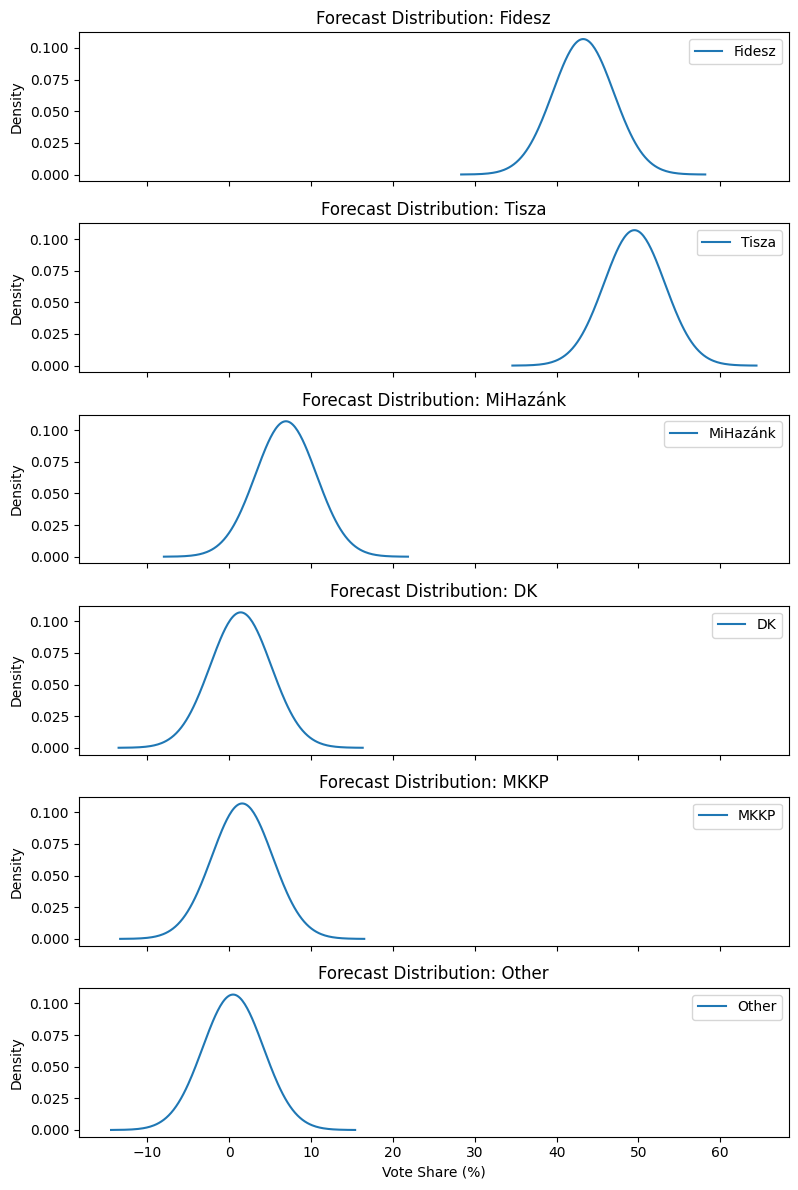

In [31]:
import matplotlib.pyplot as plt
import numpy as np

party_names = df_distr['Party'].unique()
num_parties = len(party_names)

fig, axes = plt.subplots(num_parties, 1, figsize=(8, 2 * num_parties), sharex=True)

for i, party in enumerate(party_names):
    ax = axes[i] if num_parties > 1 else axes
    mu = df_distr.loc[df_distr['Party'] == party, 'Mu'].values[0]
    sigma = df_distr.loc[df_distr['Party'] == party, 'Sigma'].values[0]
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, y, label=f'{party}')
    ax.set_title(f'Forecast Distribution: {party}')
    ax.set_ylabel('Density')
    ax.legend()

axes[-1].set_xlabel('Vote Share (%)')
plt.tight_layout()
plt.show()

#### 4.3 Handling correlations between parties

It would be wrong to draw each party's vote share independently - if one party does better than expected, another must do worse. Draw the full vector of party vote shares from a Dirichlet distribution parameterized to match the means μ(k) and the variance σ(k)². The Dirichlet naturally enforces that shares sum to 100% and introduces negative correlations. Fitting the Dirichlet concentration parameters to match your desired means and variances requires a small numerical routine. The important thing is that the draws sum to approximately 100% and that parties' errors are not independent.

In [32]:
np.random.seed(42)

draws = correl_parties(df_distr, n_draws=1000)

In [33]:
print(draws[:5])

[[4.49703818e+01 4.59454224e+01 5.50370543e+00 2.80105296e+00
  7.79431757e-01 5.69370066e-06]
 [3.88883639e+01 5.34631560e+01 7.16017360e+00 4.42090485e-01
  1.75196151e-02 2.86963888e-02]
 [4.90802357e+01 4.16549247e+01 4.32256034e+00 2.05998613e-01
  1.08616488e+00 3.65011574e+00]
 [4.02054396e+01 4.90825585e+01 6.73023750e+00 3.71331179e+00
  2.31008839e-01 3.74436761e-02]
 [3.49917821e+01 5.37282259e+01 9.52125202e+00 2.90560118e-01
  1.39190144e+00 7.62784641e-02]]


## 5. From National Vote Shares to Distributions

Polls tell you national (listás) vote shares, but seats are won in 106 individual districts. You need to translate a national-level forecast into 106 district-level results. 

#### 5.1 Compute District Swing Coeffiecient

<small>

**a. District-level deviation (per election)**: For each district $d$, party $k$, and election $t$, compute how much the district differs from the national result:

$$
\Delta_t(d, k) = \text{Election}_t^{\text{district}}(d, k) - \text{Election}_t^{\text{national}}(k)
$$


**b. Average structural deviation**: Compute the average deviation across all elections in the dataset:

$$
\bar{\Delta}(d, k) = \frac{1}{T} \sum_{t=1}^{T} \Delta_t(d, k)
$$

where $T$ is the number of elections.


**c. Interpretation**: This average captures the stable geographic structure:

- Positive values → district is consistently stronger for party $k$ than the national average  
- Negative values → district is consistently weaker for party $k$  


**d. Example**: If Fidesz received 44% nationally in the 2024 EP election but 52% in district $d$, then:

$$
\Delta(d, \text{Fidesz}) = +8 \text{ percentage points}
$$

</small>

In [34]:
swing_df = swing_coef(df_ep_trans_agg)
display(swing_df)

Party6,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,1.0,BUDAPEST,1.0,-9.099355,2.741655,-3.012914,0.636007,3.218472,5.516135
1,1.0,BUDAPEST,2.0,-11.952408,3.393239,-2.999090,2.857955,2.972617,5.727687
2,1.0,BUDAPEST,3.0,-9.969830,3.161313,-3.548133,0.158926,5.224542,4.973182
3,1.0,BUDAPEST,4.0,-11.649828,5.386845,-3.311200,2.530522,2.525411,4.518249
4,1.0,BUDAPEST,5.0,-13.182003,2.067439,-2.936836,3.157451,3.665439,7.228510
...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,1.593146,-1.683245,-0.090402,0.742487,-0.320080,-0.241905
102,19.0,VESZPRÉM,4.0,8.748751,-5.435834,0.136977,-0.383020,-1.035795,-2.031079
103,20.0,ZALA,1.0,6.265682,-1.428539,-0.465173,-1.775502,-0.981304,-1.615164
104,20.0,ZALA,2.0,7.670615,-2.825028,0.337434,-2.295945,-0.815926,-2.071150


#### 5.2 Project district results for a given national draw

<small>

**a. District-level projection**: Given a drawn national (listás) vote share π(k), compute the projected vote share in each district:

$$
\text{vote}(d, k) = \pi(k) + \Delta(d, k) + \varepsilon(d)
$$

where  
- $\Delta(d, k)$ = district-specific deviation from the national baseline  
- $\varepsilon(d) \sim \mathcal{N}(0, \sigma_d^2)$ = district-level noise term  


**b. Calibration of district noise**: The variance parameter $\sigma_d$ should be calibrated via backtesting:

- Use the 2019 EP election as the baseline  
- Predict 2022 results using the swing model  
- Estimate $\sigma_d$ from the distribution of district-level residuals  


**c. Post-processing of vote shares**: After computing $\text{vote}(d, k)$ for all parties in a district:

- Clip negative values to zero  
- Renormalize vote shares so that:
  
$$
\sum_k \text{vote}(d, k) = 1
$$


**d. Seat allocation rule (SMD winner)**: The winning party in district $d$ is:

$$
\arg\max_k \text{vote}(d, k)
$$

</small>

In [35]:
np.random.seed(42)

sigma_d_calibrated = calibrate_sigma_d(df_list, df_oevk, df_ep_trans_agg)
print(f"Calibrated σ_d: {sigma_d_calibrated:.4f}")

Calibrated σ_d: 3.3814


In [36]:
national_draw = {party: df_distr.loc[df_distr['Party'] == party, 'Mu'].values[0] for party in ['Fidesz', 'Tisza', 'MiHazánk', 'DK', 'MKKP', 'Other']}
district_projection = OEVK_projection(national_draw, swing_df, sigma_d=sigma_d_calibrated, random_state=42)
display(district_projection)

,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,36.214664,50.170057,6.636008,5.356731,0.000000,1.622540,Tisza
1,1.0,BUDAPEST,2.0,30.179080,49.304131,3.676922,1.294098,7.155254,8.390515,Tisza
2,1.0,BUDAPEST,3.0,31.851257,53.701286,4.710210,0.000000,7.651295,2.085953,Tisza
3,1.0,BUDAPEST,4.0,32.430764,51.343982,2.800584,1.515187,7.726252,4.183231,Tisza
4,1.0,BUDAPEST,5.0,26.907379,47.376089,5.439001,5.434898,6.240642,8.601990,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,46.102511,47.969996,1.099923,3.839058,0.000000,0.988512,Tisza
102,19.0,VESZPRÉM,4.0,47.158673,45.559995,4.328860,0.000000,2.952472,0.000000,Fidesz
103,20.0,ZALA,1.0,44.377213,49.569864,4.645924,0.000000,1.406998,0.000000,Tisza
104,20.0,ZALA,2.0,49.095522,41.961039,5.485359,3.458080,0.000000,0.000000,Fidesz


## 6. Seat Allocation

In [37]:
parliament_seats = seat_simulated(district_projection, df_distr, df_list=df_list, df_oevk=df_oevk, df_ep_trans_agg=df_ep_trans_agg, year=2026)
display(parliament_seats)

,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,81,110,8,0,0,0


## 7. Validation

**backtest the entire pipeline on 2022**: use pre-2022 polls, estimate pollster bias from 2014 and 2018 only, use the 2019 EP election as the district swing baseline, run the simulation, and compare the output distribution to the actual 2022 result. If the actual outcome falls well outside your 95% interval, something needs adjusting

In [38]:
comparison_df = backtesting(
        df_polls,
        df_list,
        df_oevk,
        df_ep_trans_agg,
        df_seats=df_seats,
        sigma_poll=None,
        sigma_d=sigma_d_calibrated,
        n_sim=1000,
        random_state=42
    )
display(comparison_df)

,Party,Simulated Mean,95% CI,Actual Seats,Within 95% CI
0,Fidesz,118,60–156,135,Yes
1,Tisza,0,0–0,0,Yes
2,MiHazánk,6,4–9,6,Yes
3,DK,75,38–133,57,Yes
4,MKKP,0,0–0,0,Yes
5,Other,0,0–0,1,No


Note: 2022 polls were **not very accurate**

https://kozvelemeny.org/2024/05/27/miert-tevedtek-akkorat-a-valasztasi-kozvelemeny-kutatasok-2022-tavaszan-es-mi-varhato-ez-alapjan-2024-ben/

## 8. Base Model

Note: Uses 2022 turnout numbers for the simulation.

For s = 1 to 1000:
    
    1. Draw national vote shares π(k) from the Step 3 distributions
    
    2. Compute district results: vote(d,k) = π(k) + Δ(d,k) + noise 
    
    3. Determine 106 SMD winners
    
    4. Compute fragment votes and allocate 93 list seats via d'Hondt 
    
    5. Record total seats per party


In [39]:
np.random.seed(42)

sim_results, oevk_means, oevk_vote_counts, national_vote_shares = simulation(
    df_distr, 
    swing_df, 
    df_list=df_list, 
    df_oevk=df_oevk, 
    df_ep_trans_agg=df_ep_trans_agg, 
    sigma_d=sigma_d_calibrated, 
    n_sim=1000, year=2026, 
    random_state=42)
display(sim_results)
display(oevk_means)
display(oevk_vote_counts)
display(national_vote_shares)

,Party,Mean seats,95% CI,P(majority),P(supermajority)
0,Fidesz,81,43–133,23%,3%
1,Tisza,110,59–149,66%,19%
2,MiHazánk,8,5–11,0%,0%
3,DK,0,0–0,0%,0%
4,MKKP,0,0–0,0%,0%
5,Other,0,0–0,0%,0%


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,32.444926,50.175004,4.125582,2.596815,4.720114,5.937559,Tisza
1,1.0,BUDAPEST,2.0,30.076209,51.013045,4.175729,4.284845,4.501215,5.948956,Tisza
2,1.0,BUDAPEST,3.0,31.447436,50.683671,3.674386,2.211949,6.711552,5.271006,Tisza
3,1.0,BUDAPEST,4.0,29.893456,52.976895,4.049212,4.131269,3.954031,4.995136,Tisza
4,1.0,BUDAPEST,5.0,28.611097,49.844331,4.284516,4.544940,5.200336,7.514781,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,42.313137,45.079549,6.662343,2.639622,1.892647,1.412702,Tisza
102,19.0,VESZPRÉM,4.0,48.483956,40.685624,6.663234,1.794737,1.685532,0.686916,Fidesz
103,20.0,ZALA,1.0,45.889624,44.444583,6.141626,1.137824,1.550286,0.836057,Fidesz
104,20.0,ZALA,2.0,47.037023,42.633900,6.875779,0.983666,1.697794,0.771839,Fidesz


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,14579,22546,1854,1167,2121,2668,Tisza
1,1.0,BUDAPEST,2.0,16144,27383,2241,2300,2416,3193,Tisza
2,1.0,BUDAPEST,3.0,16446,26506,1922,1157,3510,2757,Tisza
3,1.0,BUDAPEST,4.0,17279,30621,2340,2388,2285,2887,Tisza
4,1.0,BUDAPEST,5.0,11448,19944,1714,1819,2081,3007,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,19769,21061,3113,1233,884,660,Tisza
102,19.0,VESZPRÉM,4.0,23047,19340,3167,853,801,327,Fidesz
103,20.0,ZALA,1.0,25191,24397,3371,625,851,459,Fidesz
104,20.0,ZALA,2.0,24158,21897,3531,505,872,396,Fidesz


,Party,Mean_%,Median_%,Std_%,95% CI Low_%,95% CI High_%
0,Fidesz,41.920700,41.794069,5.734526,30.705020,53.307368
1,Tisza,47.974802,47.910574,5.726828,36.772634,59.669165
2,MiHazánk,6.867364,6.562167,2.983798,2.118443,13.311134
3,DK,1.295728,0.850333,1.410716,0.028713,5.203784
4,MKKP,1.506224,1.057183,1.491432,0.033930,5.913714
5,Other,0.435182,0.115137,0.753142,0.000007,2.854571


In [40]:
oevk_means.to_excel('output/base/oevk_perc.xlsx', index=False)
oevk_vote_counts.to_excel('output/base/oevk_counts.xlsx', index=False)
sim_results.to_excel('output/base/sim_result.xlsx')

In [41]:
# Aggregate oevk_vote_counts to Megye level
parties = ['Fidesz', 'Tisza', 'MiHazánk', 'DK', 'MKKP', 'Other']
megye_means = oevk_vote_counts.groupby(['Megye_No', 'Megye'])[parties].sum().reset_index()
display(megye_means)
megye_means.to_excel('output/base/megye_counts.xlsx')

,Megye_No,Megye,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,1.0,BUDAPEST,289314,479895,45863,52831,37777,43752
1,2.0,BARANYA,83520,88052,12464,6396,4564,2908
2,3.0,BÁCS-KISKUN,119109,121784,22415,3152,4915,1904
3,4.0,BÉKÉS,74697,83466,15193,3009,2917,1842
4,5.0,BORSOD-ABAÚJ-ZEMPLÉN,143516,144178,23877,6956,5052,3316
5,6.0,CSONGRÁD,78509,109717,18763,5200,5851,7736
6,7.0,FEJÉR,100409,109498,17421,4179,5745,2893
7,8.0,GYŐR-MOSON-SOPRON,113195,121519,16681,2673,4836,2438
8,9.0,HAJDÚ-BIHAR,118849,128109,19817,2730,4341,2425
9,10.0,HEVES,69726,73164,11421,2745,2517,2181


# Extension: Different Participation Levels

#### 9.1 Participation: 75%

In [42]:
np.random.seed(42)

sim_results, oevk_means, oevk_vote_counts, national_vote_shares = simulation(
    df_distr, 
    swing_df, 
    df_list=df_list, 
    df_oevk=df_oevk, 
    df_ep_trans_agg=df_ep_trans_agg, 
    sigma_d=sigma_d_calibrated, 
    n_sim=1000, 
    year=2026, 
    participation=0.75,
    random_state=42)
display(sim_results)
display(oevk_means)
display(oevk_vote_counts)
display(national_vote_shares)

,Party,Mean seats,95% CI,P(majority),P(supermajority)
0,Fidesz,81,43–133,23%,3%
1,Tisza,110,59–149,66%,19%
2,MiHazánk,8,5–11,0%,0%
3,DK,0,0–0,0%,0%
4,MKKP,0,0–0,0%,0%
5,Other,0,0–0,0%,0%


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,32.444926,50.175004,4.125582,2.596815,4.720114,5.937559,Tisza
1,1.0,BUDAPEST,2.0,30.076209,51.013045,4.175729,4.284845,4.501215,5.948956,Tisza
2,1.0,BUDAPEST,3.0,31.447436,50.683671,3.674386,2.211949,6.711552,5.271006,Tisza
3,1.0,BUDAPEST,4.0,29.893456,52.976895,4.049212,4.131269,3.954031,4.995136,Tisza
4,1.0,BUDAPEST,5.0,28.611097,49.844331,4.284516,4.544940,5.200336,7.514781,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,42.313137,45.079549,6.662343,2.639622,1.892647,1.412702,Tisza
102,19.0,VESZPRÉM,4.0,48.483956,40.685624,6.663234,1.794737,1.685532,0.686916,Fidesz
103,20.0,ZALA,1.0,45.889624,44.444583,6.141626,1.137824,1.550286,0.836057,Fidesz
104,20.0,ZALA,2.0,47.037023,42.633900,6.875779,0.983666,1.697794,0.771839,Fidesz


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,14541,22486,1849,1164,2115,2661,Tisza
1,1.0,BUDAPEST,2.0,15076,25570,2093,2148,2256,2982,Tisza
2,1.0,BUDAPEST,3.0,15184,24472,1774,1068,3241,2545,Tisza
3,1.0,BUDAPEST,4.0,15965,28293,2163,2206,2112,2668,Tisza
4,1.0,BUDAPEST,5.0,12642,22024,1893,2008,2298,3320,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,21426,22827,3374,1337,958,715,Tisza
102,19.0,VESZPRÉM,4.0,24859,20860,3416,920,864,352,Fidesz
103,20.0,ZALA,1.0,25783,24971,3451,639,871,470,Fidesz
104,20.0,ZALA,2.0,26024,23588,3804,544,939,427,Fidesz


,Party,Mean_%,Median_%,Std_%,95% CI Low_%,95% CI High_%
0,Fidesz,41.920700,41.794069,5.734526,30.705020,53.307368
1,Tisza,47.974802,47.910574,5.726828,36.772634,59.669165
2,MiHazánk,6.867364,6.562167,2.983798,2.118443,13.311134
3,DK,1.295728,0.850333,1.410716,0.028713,5.203784
4,MKKP,1.506224,1.057183,1.491432,0.033930,5.913714
5,Other,0.435182,0.115137,0.753142,0.000007,2.854571


In [43]:
oevk_means.to_excel('output/75/oevk_perc75.xlsx', index=False)
oevk_vote_counts.to_excel('output/75/oevk_counts75.xlsx', index=False)
sim_results.to_excel('output/75/sim_result75.xlsx')

In [44]:
# Aggregate oevk_vote_counts to Megye level
parties = ['Fidesz', 'Tisza', 'MiHazánk', 'DK', 'MKKP', 'Other']
megye_means = oevk_vote_counts.groupby(['Megye_No', 'Megye'])[parties].sum().reset_index()
display(megye_means)
megye_means.to_excel('output/75/megye_counts75.xlsx')

,Megye_No,Megye,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,1.0,BUDAPEST,291224,482757,46286,53503,38005,44016
1,2.0,BARANYA,94742,99007,14086,7130,5116,3247
2,3.0,BÁCS-KISKUN,134453,136982,25427,3550,5522,2149
3,4.0,BÉKÉS,85831,95526,17449,3446,3336,2108
4,5.0,BORSOD-ABAÚJ-ZEMPLÉN,170058,169041,28157,8112,5912,3874
5,6.0,CSONGRÁD,84682,118404,20251,5633,6322,8210
6,7.0,FEJÉR,107093,115780,18601,4451,6030,3078
7,8.0,GYŐR-MOSON-SOPRON,116475,125282,17178,2760,4988,2522
8,9.0,HAJDÚ-BIHAR,137721,146566,22904,3124,4936,2774
9,10.0,HEVES,76952,80544,12612,3016,2770,2410


#### 9.2 Participation: 85%

In [45]:
np.random.seed(42)

sim_results, oevk_means, oevk_vote_counts, national_vote_shares = simulation(
    df_distr, 
    swing_df, 
    df_list=df_list, 
    df_oevk=df_oevk, 
    df_ep_trans_agg=df_ep_trans_agg, 
    sigma_d=sigma_d_calibrated, 
    n_sim=1000, 
    year=2026, 
    participation=0.85,
    random_state=42)
display(sim_results)
display(oevk_means)
display(oevk_vote_counts)
display(national_vote_shares)

,Party,Mean seats,95% CI,P(majority),P(supermajority)
0,Fidesz,81,43–133,23%,3%
1,Tisza,110,59–149,66%,19%
2,MiHazánk,8,5–11,0%,0%
3,DK,0,0–0,0%,0%
4,MKKP,0,0–0,0%,0%
5,Other,0,0–0,0%,0%


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,32.444926,50.175004,4.125582,2.596815,4.720114,5.937559,Tisza
1,1.0,BUDAPEST,2.0,30.076209,51.013045,4.175729,4.284845,4.501215,5.948956,Tisza
2,1.0,BUDAPEST,3.0,31.447436,50.683671,3.674386,2.211949,6.711552,5.271006,Tisza
3,1.0,BUDAPEST,4.0,29.893456,52.976895,4.049212,4.131269,3.954031,4.995136,Tisza
4,1.0,BUDAPEST,5.0,28.611097,49.844331,4.284516,4.544940,5.200336,7.514781,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,42.313137,45.079549,6.662343,2.639622,1.892647,1.412702,Tisza
102,19.0,VESZPRÉM,4.0,48.483956,40.685624,6.663234,1.794737,1.685532,0.686916,Fidesz
103,20.0,ZALA,1.0,45.889624,44.444583,6.141626,1.137824,1.550286,0.836057,Fidesz
104,20.0,ZALA,2.0,47.037023,42.633900,6.875779,0.983666,1.697794,0.771839,Fidesz


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,16479,25484,2095,1319,2397,3016,Tisza
1,1.0,BUDAPEST,2.0,17086,28979,2372,2434,2557,3379,Tisza
2,1.0,BUDAPEST,3.0,17208,27735,2011,1210,3673,2884,Tisza
3,1.0,BUDAPEST,4.0,18094,32065,2451,2501,2393,3023,Tisza
4,1.0,BUDAPEST,5.0,14328,24961,2146,2276,2604,3763,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,24283,25871,3823,1515,1086,811,Tisza
102,19.0,VESZPRÉM,4.0,28173,23642,3872,1043,979,399,Fidesz
103,20.0,ZALA,1.0,29221,28301,3911,725,987,532,Fidesz
104,20.0,ZALA,2.0,29494,26733,4311,617,1065,484,Fidesz


,Party,Mean_%,Median_%,Std_%,95% CI Low_%,95% CI High_%
0,Fidesz,41.920700,41.794069,5.734526,30.705020,53.307368
1,Tisza,47.974802,47.910574,5.726828,36.772634,59.669165
2,MiHazánk,6.867364,6.562167,2.983798,2.118443,13.311134
3,DK,1.295728,0.850333,1.410716,0.028713,5.203784
4,MKKP,1.506224,1.057183,1.491432,0.033930,5.913714
5,Other,0.435182,0.115137,0.753142,0.000007,2.854571


In [46]:
oevk_means.to_excel('output/85/oevk_perc85.xlsx', index=False)
oevk_vote_counts.to_excel('output/85/oevk_counts85.xlsx', index=False)
sim_results.to_excel('output/85/sim_result85.xlsx')

In [47]:
# Aggregate oevk_vote_counts to Megye level
parties = ['Fidesz', 'Tisza', 'MiHazánk', 'DK', 'MKKP', 'Other']
megye_means = oevk_vote_counts.groupby(['Megye_No', 'Megye'])[parties].sum().reset_index()
display(megye_means)
megye_means.to_excel('output/85/megye_counts85.xlsx')

,Megye_No,Megye,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,1.0,BUDAPEST,330054,547125,52459,60636,43070,49885
1,2.0,BARANYA,107372,112208,15963,8080,5800,3680
2,3.0,BÁCS-KISKUN,152380,155247,28817,4024,6258,2433
3,4.0,BÉKÉS,97273,108262,19776,3905,3780,2389
4,5.0,BORSOD-ABAÚJ-ZEMPLÉN,192732,191580,31912,9193,6703,4391
5,6.0,CSONGRÁD,95973,134192,22952,6385,7163,9305
6,7.0,FEJÉR,121372,131218,21081,5045,6833,3488
7,8.0,GYŐR-MOSON-SOPRON,132004,141985,19469,3129,5652,2859
8,9.0,HAJDÚ-BIHAR,156085,166108,25960,3540,5593,3145
9,10.0,HEVES,87212,91283,14293,3418,3138,2732


# 10. Extension: Exclude Fidesz-biased pollsters 

#### Alapjogokért Központ, Századvég, and Nézpőnt

In [48]:
# Filter out the three Fidesz-biased pollsters
excluded_pollsters = ['Alapjogokért Központ', 'Századvég', 'Nézőpont']
df_polls_filtered = df_polls[~df_polls['Adatgazda'].isin(excluded_pollsters)].copy()

print(f"Original number of polls: {len(df_polls)}")
print(f"Filtered number of polls: {len(df_polls_filtered)}")
print(df_polls['Adatgazda'].unique())
print(df_polls_filtered['Adatgazda'].unique())


Original number of polls: 63
Filtered number of polls: 42
<StringArray>
[              'Medián',            'Századvég',             'Nézőpont',
                 'IDEA',                  'ZRI',             'Publicus',
              'Iránytű',           'Real-PR 93',     'Társadalomkutató',
           'Republikon', 'Alapjogokért Központ']
Length: 11, dtype: str
<StringArray>
[          'Medián',             'IDEA',              'ZRI',
         'Publicus',          'Iránytű',       'Real-PR 93',
 'Társadalomkutató',       'Republikon']
Length: 8, dtype: str


In [49]:
# Recompute pollster metrics using filtered polls
df_bias_filtered = pollster_bias(
    df_polls_filtered,
    df_list,
    pollster_col='Adatgazda',
    party_cols=['Other', 'Fidesz', 'DK', 'MKKP', 'MiHazánk', 'Tisza'],
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6', 
    result_vote_col='Vote_Perc'
)
display(df_bias_filtered)


,Other,Fidesz,DK,MKKP,MiHazánk,Tisza
Medián,-0.270151,1.735296,-0.240984,0.058178,-1.512946,-2.814678
IDEA,2.98275,-4.319638,3.617088,-0.316822,-2.012946,-3.814678
ZRI,1.73275,-1.569638,3.117088,-1.066822,-2.012946,-2.814678
Publicus,5.23275,-3.319638,2.367088,-1.316822,-2.679612,-4.814678
Iránytű,4.895001,-1.619501,-1.635886,0.674326,-2.563571,-3.814678
Real-PR 93,-1.51883,-2.397619,4.113365,1.559544,-1.349121,-1.814678
Társadalomkutató,-2.51883,1.102381,2.613365,1.059544,-1.349121,-4.814678
Republikon,3.716342,-7.37519,15.850718,1.409355,-1.786547,-12.814678


In [50]:
# Recompute quality metrics
df_quality_filtered = pollster_quality(
    df_polls_filtered,
    df_list,
    pollster_col='Adatgazda',
    party_col='Party6',
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6',
    result_vote_col='Vote_Perc'
)
display(df_quality_filtered)


,Quality
Medián,2.703031
IDEA,4.143354
ZRI,3.147842
Publicus,4.793212
Iránytű,3.940598
Real-PR 93,2.939854
Társadalomkutató,3.411395
Republikon,6.382554


In [51]:
# Recompute industry-wide polling error
sigma_filtered = pollster_sigma(
    df_polls_filtered,
    df_list,
    pollster_col='Adatgazda',
    party_col='Party6',
    year_col='Választás',
    result_year_col='Year',
    result_party_col='Party6',
    result_vote_col='Vote_Perc'
)
display(sigma_filtered)


,sigma_poll
0,3.927743


In [52]:
# Recompute bias-corrected polling average
df_avg_filtered = polling_avg(
    df_polls_filtered,
    df_bias_filtered,
    df_quality_filtered,
    election_date="2026-04-12",
    lambda_decay=0.03,
    party_list=None
)
display(df_avg_filtered)


,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,39.20095,54.521816,7.193158,0.481897,3.21522,-1.82814


In [53]:
# Recompute forecast distribution with filtered data
df_distr_filtered = forecast_distr(
    df_avg_filtered,                
    sigma_filtered['sigma_poll'].values[0], 
    df_polls_filtered,              
    election_date="2026-04-12", 
    alpha=0.1,             
    party_list=None        
)
display(df_distr_filtered)


,Party,Mu,Sigma
0,Fidesz,39.200950,4.032483
1,Tisza,54.521816,4.032483
2,MiHazánk,7.193158,4.032483
3,DK,0.481897,4.032483
4,MKKP,3.215220,4.032483
5,Other,-1.828140,4.032483


In [54]:
np.random.seed(42)

sim_results_filtered, oevk_means_filtered, oevk_vote_counts_filtered, national_vote_shares_filtered = simulation(
    df_distr_filtered, 
    swing_df, 
    df_list=df_list, 
    df_oevk=df_oevk, 
    df_ep_trans_agg=df_ep_trans_agg, 
    sigma_d=sigma_d_calibrated, 
    n_sim=1000, 
    year=2026, 
    random_state=42)
display(sim_results_filtered)
display(oevk_means_filtered)
display(oevk_vote_counts_filtered)
display(national_vote_shares_filtered)

,Party,Mean seats,95% CI,P(majority),P(supermajority)
0,Fidesz,63,35–115,7%,0%
1,Tisza,128,76–156,89%,50%
2,MiHazánk,8,5–12,0%,0%
3,DK,0,0–0,0%,0%
4,MKKP,0,0–0,0%,0%
5,Other,0,0–0,0%,0%


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,28.045350,53.937188,4.283891,1.961092,6.265819,5.506660,Tisza
1,1.0,BUDAPEST,2.0,25.701661,54.852499,4.344095,3.516967,6.059010,5.525769,Tisza
2,1.0,BUDAPEST,3.0,27.087439,54.313386,3.840109,1.613089,8.300811,4.845166,Tisza
3,1.0,BUDAPEST,4.0,25.525360,56.744427,4.266307,3.389246,5.498345,4.576315,Tisza
4,1.0,BUDAPEST,5.0,24.232820,53.653766,4.478984,3.763836,6.799002,7.071593,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,38.058298,48.843578,6.785103,2.020778,3.124790,1.167453,Tisza
102,19.0,VESZPRÉM,4.0,44.290213,44.325270,6.783921,1.313023,2.753158,0.534414,Tisza
103,20.0,ZALA,1.0,41.671965,47.995334,6.243938,0.754893,2.657147,0.676723,Tisza
104,20.0,ZALA,2.0,42.773714,46.174672,6.997693,0.655693,2.802721,0.595507,Tisza


,Megye_No,Megye,OEVK,Fidesz,Tisza,MiHazánk,DK,MKKP,Other,Winner
0,1.0,BUDAPEST,1.0,12602,24236,1925,881,2815,2474,Tisza
1,1.0,BUDAPEST,2.0,13796,29444,2332,1888,3252,2966,Tisza
2,1.0,BUDAPEST,3.0,14166,28404,2008,844,4341,2534,Tisza
3,1.0,BUDAPEST,4.0,14754,32799,2466,1959,3178,2645,Tisza
4,1.0,BUDAPEST,5.0,9696,21468,1792,1506,2720,2830,Tisza
...,...,...,...,...,...,...,...,...,...,...
101,19.0,VESZPRÉM,3.0,17781,22820,3170,944,1460,545,Tisza
102,19.0,VESZPRÉM,4.0,21053,21070,3225,624,1309,254,Tisza
103,20.0,ZALA,1.0,22875,26347,3428,414,1459,371,Tisza
104,20.0,ZALA,2.0,21969,23715,3594,337,1439,306,Tisza


,Party,Mean_%,Median_%,Std_%,95% CI Low_%,95% CI High_%
0,Fidesz,37.580568,37.537027,6.067508,2.578605e+01,49.946984
1,Tisza,51.843297,51.756839,6.238887,3.993763e+01,63.793095
2,MiHazánk,6.987695,6.406127,3.409189,2.018289e+00,14.771094
3,DK,0.427977,0.078534,0.904577,5.512719e-07,2.890528
4,MKKP,3.160463,2.542112,2.333303,2.520873e-01,9.108822
5,Other,0.000000,0.000000,0.000000,0.000000e+00,0.000000


In [55]:
# Export filtered results to Excel
oevk_means_filtered.to_excel('output/filtered/oevk_perc_filtered.xlsx', index=False)
oevk_vote_counts_filtered.to_excel('output/filtered/oevk_counts_filtered.xlsx', index=False)
sim_results_filtered.to_excel('output/filtered/sim_result_filtered.xlsx')


In [56]:
# Aggregate oevk_vote_counts to Megye level
parties = ['Fidesz', 'Tisza', 'MiHazánk', 'DK', 'MKKP', 'Other']
megye_means_filtered = oevk_vote_counts_filtered.groupby(['Megye_No', 'Megye'])[parties].sum().reset_index()
display(megye_means_filtered)
megye_means_filtered.to_excel('output/filtered/megye_means_filtered.xlsx')

,Megye_No,Megye,Fidesz,Tisza,MiHazánk,DK,MKKP,Other
0,1.0,BUDAPEST,248220,516459,47344,45359,52027,40022
1,2.0,BARANYA,75035,95433,12733,5152,7112,2442
2,3.0,BÁCS-KISKUN,107523,131510,22667,2127,7966,1482
3,4.0,BÉKÉS,67068,90115,15394,2128,4936,1485
4,5.0,BORSOD-ABAÚJ-ZEMPLÉN,129792,156295,24248,5260,8613,2687
5,6.0,CSONGRÁD,68828,118020,19026,4047,8787,7066
6,7.0,FEJÉR,90112,118148,17679,3059,8751,2394
7,8.0,GYŐR-MOSON-SOPRON,102057,130747,16963,1781,7822,1971
8,9.0,HAJDÚ-BIHAR,107153,137955,20093,1787,7342,1937
9,10.0,HEVES,62893,79210,11651,1972,4217,1812


# 11. Extension: Incumbent dummy

#### Adding even a simple binary indicator (incumbent running: yes/no) to the district-level projection.

In [57]:
# Create incumbent dummy: identifies 2022 SMD winners and checks if they're running in 2026
incumbent_by_district = create_incumbent_dummy(df_oevk, df_2026_candidates_filtered)

In [58]:
display(incumbent_by_district)

,Megye,OEVK_No,incumbent_dummy
0,BARANYA,1,0
1,BARANYA,2,1
2,BARANYA,3,1
3,BARANYA,4,1
4,BORSOD-ABAÚJ-ZEMPLÉN,1,1
...,...,...,...
101,VESZPRÉM,3,1
102,VESZPRÉM,4,0
103,ZALA,1,0
104,ZALA,2,1


# 12. Extension: Zsiday Viktor

Net real sallary change x governing party list vote share model

In [59]:
display(df_salary_vote)

,Év,Type,Net_Real_Salary_Index_4,Governing_party_list,Előző ciklus párt,Lista
0,2002,Évi átlag,0.140,0.4785,Fidesz,Területi lista
1,2006,Évi átlag,0.280,0.4863,MSZP,Területi lista
2,2010,Évi átlag,-0.025,0.1917,MSZP,Területi lista
3,2014,Évi átlag,0.039,0.4355,Fidesz,Pártlista
4,2018,Évi átlag,0.253,0.4927,Fidesz,Pártlista
5,2022,Évi átlag,0.255,0.5413,Fidesz,Pártlista
6,2026,Január,0.139,NaN,Fidesz,Pártlista


In [60]:
df_salary_vote.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Év                       7 non-null      int64  
 1   Type                     7 non-null      str    
 2   Net_Real_Salary_Index_4  7 non-null      float64
 3   Governing_party_list     6 non-null      float64
 4   Előző ciklus párt        7 non-null      str    
 5   Lista                    7 non-null      str    
dtypes: float64(2), int64(1), str(3)
memory usage: 468.0 bytes


In [61]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Fit linear regression on historical data (all rows except 2026)
df_historical = df_salary_vote[df_salary_vote['Év'] != 2026]
X = df_historical[['Net_Real_Salary_Index_4']].values
y = df_historical['Governing_party_list'].values
model = LinearRegression().fit(X, y)

# Predict 2026 Governing_party_list value based on 2026 Net_Real_Salary_Index
salary_2026 = df_salary_vote[df_salary_vote['Év'] == 2026]['Net_Real_Salary_Index_4'].values[0]
prediction_2026 = model.predict([[salary_2026]])[0]

print(f"Predicted 2026 Governing Party List Vote Share: {prediction_2026:.2f}%")
print(f"R-squared on historical data: {model.score(X, y):.4f}")

Predicted 2026 Governing Party List Vote Share: 0.42%
R-squared on historical data: 0.6791


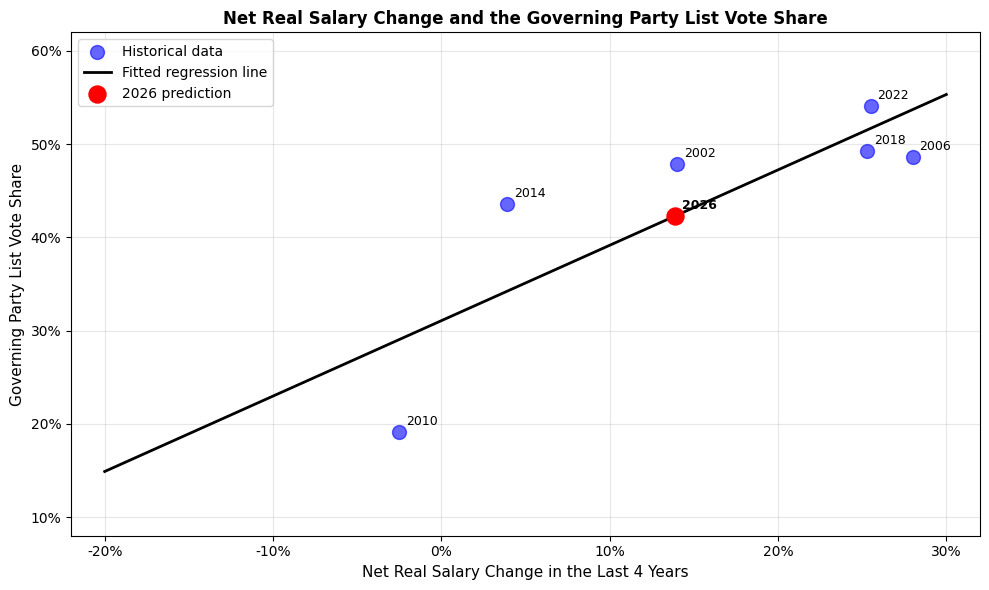

2026 Net Real Salary Index: 13.90%
Predicted 2026 Governing Party List Vote Share: 42.31%
R-squared on historical data: 0.6791


In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Prepare data
df_historical = df_salary_vote[df_salary_vote['Év'] != 2026]
X_hist = df_historical[['Net_Real_Salary_Index_4']].values.flatten() * 100  # Convert to percentage
y_hist = df_historical['Governing_party_list'].values * 100  # Convert to percentage
years_hist = df_historical['Év'].values

# Fit model
model = LinearRegression().fit(X_hist.reshape(-1, 1), y_hist)

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot historical data points (blue)
ax.scatter(X_hist, y_hist, color='blue', s=100, alpha=0.6, label='Historical data', zorder=3)

# Add year labels to historical points
for i, year in enumerate(years_hist):
    ax.annotate(str(int(year)), (float(X_hist[i]), float(y_hist[i])), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Plot regression line
x_range = np.linspace(-20, 30, 100)
y_pred_range = model.predict(x_range.reshape(-1, 1))
ax.plot(x_range, y_pred_range, color='black', linewidth=2, label='Fitted regression line', zorder=2)

# Plot 2026 prediction (red)
salary_2026 = df_salary_vote[df_salary_vote['Év'] == 2026]['Net_Real_Salary_Index_4'].values[0] * 100  # Convert to percentage
prediction_2026 = model.predict([[salary_2026]])[0]
ax.scatter([salary_2026], [prediction_2026], color='red', s=150, marker='o', 
           label='2026 prediction', zorder=4)
ax.annotate('2026', (float(salary_2026), float(prediction_2026)), 
            xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Format axes - set limits based on data range
x_min, x_max = min(X_hist.min(), salary_2026, -20), max(X_hist.max(), salary_2026, 30)
y_min, y_max = min(y_hist.min(), prediction_2026, 10), max(y_hist.max(), prediction_2026, 60)
ax.set_xlim(x_min - 2, x_max + 2)
ax.set_ylim(y_min - 2, y_max + 2)

ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x)}%'))

ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x)}%'))

# Labels and title
ax.set_xlabel('Net Real Salary Change in the Last 4 Years', fontsize=11)
ax.set_ylabel('Governing Party List Vote Share', fontsize=11)
ax.set_title('Net Real Salary Change and the Governing Party List Vote Share', fontsize=12, fontweight='bold')

# Grid and legend
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

print(f"2026 Net Real Salary Index: {salary_2026:.2f}%")
print(f"Predicted 2026 Governing Party List Vote Share: {prediction_2026:.2f}%")
print(f"R-squared on historical data: {model.score(X_hist.reshape(-1, 1), y_hist):.4f}")